# DeepScan — Fixed CNN Training

**Label convention (consistent throughout):**
- `0 = Real`
- `1 = Fake`

**Preprocessing:** `x / 255.0` → `[0, 1]`

**Key fixes vs old notebook:**
1. Image dataset: `class_names` forced to `['Real', 'Fake']` so `Real=0, Fake=1`
2. Video frames: folder `/0=Real`, `/1=Fake` (unchanged — was already correct)
3. Both datasets now use the same label convention before merging

In [ ]:
import tensorflow as tf

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Memory growth enabled on {len(gpus)} GPU(s)')

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled on 1 GPU(s)


In [ ]:
import zipfile
import os
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH   = '/content/drive/MyDrive/Dataset.zip'
EXTRACT_TO = '/content/Dataset'

print(f"Extracting '{ZIP_PATH}' to '{EXTRACT_TO}' ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)

print('Extraction complete! Folder structure:')
for root, dirs, files_list in os.walk(EXTRACT_TO):
    depth = root.replace(EXTRACT_TO, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    for f in files_list[:3]:
        print(f'{indent}  {f}')

Mounted at /content/drive
Extracting '/content/drive/MyDrive/Dataset.zip' to '/content/Dataset' ...
Extraction complete! Folder structure:
Dataset/
  Dataset/
    Image/
    Video/


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10
MAX_VIDEOS = 500
FRAME_SKIP = 30
AUTOTUNE   = tf.data.AUTOTUNE

IMAGE_DIR  = '/content/Dataset/Dataset/Image'
VIDEO_REAL = '/content/Dataset/Dataset/Video/Real'
VIDEO_FAKE = '/content/Dataset/Dataset/Video/Fake'
MODEL_PATH = '/content/Dataset/Dataset/deepfake_model.h5'

# ✅ LABEL CONVENTION — must be consistent everywhere
# 0 = Real,  1 = Fake
print('Label convention: 0=Real  1=Fake')
print(f'Config ready | IMG:{IMG_SIZE} BATCH:{BATCH_SIZE} EPOCHS:{EPOCHS}')

Label convention: 0=Real  1=Fake
Config ready | IMG:224 BATCH:32 EPOCHS:10


In [ ]:
# ── IMAGE DATASET ─────────────────────────────────────────────────────────
# ✅ FIX: Force class order to ['Real', 'Fake'] so Real=0, Fake=1
# Without this, image_dataset_from_directory sorts alphabetically:
#   Fake=0, Real=1  ← WRONG, contradicts video labels
# With class_names=['Real','Fake']:
#   Real=0, Fake=1  ← CORRECT, matches video labels

# Assuming IMAGE_DIR = 'Dataset/Dataset/Image'
def build_image_datasets(image_dir, img_size, batch_size):
    """
    Loads images from pre-split Train and Validation directories.
    Ensures class mapping: Real=0, Fake=1
    """

    # 1. Define specific paths
    train_path = os.path.join(image_dir, 'Train')
    val_path   = os.path.join(image_dir, 'Validation')

    # 2. Define shared arguments
    # We remove validation_split and subset because the folders are already split
    common_args = dict(
        image_size  = (img_size, img_size),
        batch_size  = batch_size,
        class_names = ['Real', 'Fake'],  # ✅ Force: Real=0, Fake=1
        seed        = 123
    )

    print(f"Loading Training data from: {train_path}")
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory=train_path,
        shuffle=True,
        **common_args
    )

    print(f"\nLoading Validation data from: {val_path}")
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory=val_path,
        shuffle=False, # Usually better to keep val/test order consistent
        **common_args
    )

    return train_ds, val_ds

# --- Execution ---
# Make sure IMAGE_DIR points to the folder containing 'Train' and 'Validation'
image_train_ds, image_val_ds = build_image_datasets(IMAGE_DIR, IMG_SIZE, BATCH_SIZE)

print('\n' + '-'*30)
print('Image class names:', image_train_ds.class_names)
print('✅ Expected: [Real, Fake]  →  Real=0, Fake=1')

# Final sanity check
assert image_train_ds.class_names == ['Real', 'Fake'], \
    f"❌ Class order wrong! Found {image_train_ds.class_names} instead."

Loading Training data from: /content/Dataset/Dataset/Image/Train
Found 140002 files belonging to 2 classes.

Loading Validation data from: /content/Dataset/Dataset/Image/Validation
Found 39428 files belonging to 2 classes.

------------------------------
Image class names: ['Real', 'Fake']
✅ Expected: [Real, Fake]  →  Real=0, Fake=1


In [ ]:
# ── VIDEO FRAMES → DISK ───────────────────────────────────────────────────
# ✅ Labels: /0 = Real,  /1 = Fake  (consistent with image dataset above)
import cv2
import numpy as np
import gc

FRAMES_DIR = '/content/Dataset/Dataset/frames'
os.makedirs(FRAMES_DIR + '/0', exist_ok=True)  # Real
os.makedirs(FRAMES_DIR + '/1', exist_ok=True)  # Fake

def extract_frames_to_disk(real_folder, fake_folder,
                            max_videos=MAX_VIDEOS,
                            frame_skip=FRAME_SKIP,
                            img_size=IMG_SIZE):
    EXT   = ('.mp4', '.avi', '.mov', '.mkv')
    total = 0
    for folder, label in [(real_folder, 0), (fake_folder, 1)]:
        tag    = 'Real' if label == 0 else 'Fake'
        videos = sorted([v for v in os.listdir(folder)
                         if v.lower().endswith(EXT)])[:max_videos]
        print(f'  {tag} (label={label}): {len(videos)} videos ...')
        for i, video in enumerate(videos):
            cap   = cv2.VideoCapture(os.path.join(folder, video))
            count = 0
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                if count % frame_skip == 0:
                    frame     = cv2.resize(frame, (img_size, img_size))
                    save_path = f'{FRAMES_DIR}/{label}/v{i:04d}_f{count:06d}.jpg'
                    cv2.imwrite(save_path, frame)
                    total += 1
                count += 1
            cap.release()
        print(f'    Done. Total frames so far: {total}')
        gc.collect()
    print(f'All frames saved. Total: {total}')

print('Extracting video frames ...')
extract_frames_to_disk(VIDEO_REAL, VIDEO_FAKE)

# Load from disk — /0=Real /1=Fake → sorted alphabetically: 0=Real(0), 1=Fake(1)
video_ds_full = tf.keras.preprocessing.image_dataset_from_directory(
    FRAMES_DIR,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
    shuffle    = True,
    seed       = 42,
    label_mode = 'int',
)
print('Video frame class names:', video_ds_full.class_names)
print('✅ Expected: [0, 1]  →  0=Real, 1=Fake')

video_ds = (video_ds_full
            .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0,
                               tf.cast(y, tf.int32)),
                 num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

print('Video dataset ready.')

Extracting video frames ...
  Real (label=0): 500 videos ...
    Done. Total frames so far: 8976
  Fake (label=1): 500 videos ...
    Done. Total frames so far: 17952
All frames saved. Total: 17952
Found 17952 files belonging to 2 classes.
Video frame class names: ['0', '1']
✅ Expected: [0, 1]  →  0=Real, 1=Fake
Video dataset ready.


In [ ]:
# ── MERGE IMAGE + VIDEO ───────────────────────────────────────────────────
def normalize_and_merge(image_ds, video_ds, autotune):
    image_ds = (image_ds
                .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0,
                                   tf.cast(y, tf.int32)),
                     num_parallel_calls=autotune)
                .prefetch(autotune))
    return image_ds.concatenate(video_ds)

train_ds = normalize_and_merge(image_train_ds, video_ds, AUTOTUNE)

val_ds = (image_val_ds
          .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0,
                             tf.cast(y, tf.int32)),
               num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

print('✅ Train + val datasets merged.')
print('   Both use: 0=Real, 1=Fake, x/255 normalisation')

✅ Train + val datasets merged.
   Both use: 0=Real, 1=Fake, x/255 normalisation


In [ ]:
# ── BUILD MODEL ───────────────────────────────────────────────────────────
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

def build_model(img_size):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet',
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x      = base(inputs, training=False)
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dense(128, activation='relu')(x)
    x      = layers.Dropout(0.5)(x)
    x      = layers.BatchNormalization()(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model, base

model, base_model = build_model(IMG_SIZE)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [ ]:
# ── CALLBACKS ─────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_PATH, save_best_only=True,
                    monitor='val_accuracy', verbose=1),
]

In [ ]:
# ── PHASE 1: Train classifier head ────────────────────────────────────────
print('\n===== PHASE 1: Training classifier head =====')
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


===== PHASE 1: Training classifier head =====
Epoch 1/10
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7191 - auc: 0.7939 - loss: 0.5525 - precision: 0.7284 - recall: 0.7005
Epoch 1: val_accuracy improved from None to 0.72413, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 1: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 330s 62ms/step - accuracy: 0.7221 - auc: 0.8079 - loss: 0.5318 - precision: 0.7297 - recall: 0.7055 - val_accuracy: 0.7241 - val_auc: 0.8594 - val_loss: 0.5414 - val_precision: 0.6592 - val_recall: 0.9237 - learning_rate: 1.0000e-04
Epoch 2/10
4935/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7753 - auc: 0.8598 - loss: 0.4643 - precision: 0.7977 - recall: 0.7382
Epoch 2: val_accuracy improved from 0.72413 to 0.73851, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 2: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 218s 44ms/step - accuracy: 0.7513 - auc: 0.8431 - loss: 0.4826 - precision: 0.7625 - recall: 0.7301 - val_accuracy: 0.7385 - val_auc: 0.8580 - val_loss: 0.5358 - val_precision: 0.6773 - val_recall: 0.9076 - learning_rate: 1.0000e-04
Epoch 3/10
4936/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7837 - auc: 0.8697 - loss: 0.4509 - precision: 0.8102 - recall: 0.7413
Epoch 3: val_accuracy did not improve from 0.73851
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 217s 44ms/step - accuracy: 0.7583 - auc: 0.8510 - loss: 0.4716 - precision: 0.7709 - recall: 0.7350 - val_accuracy: 0.7382 - val_auc: 0.8681 - val_loss: 0.5239 - val_precision: 0.6726 - val_recall: 0.9244 - learning_rate: 1.0000e-04
Epoch 4/10
4936/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7907 - auc: 0.8773 - loss: 0.4384 - precision: 0.8170 - recall: 0.7501
Epoch 4: val_accuracy did not improve from 0.73851
4937/4937 ━━


Epoch 6: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 257s 52ms/step - accuracy: 0.7707 - auc: 0.8643 - loss: 0.4530 - precision: 0.7849 - recall: 0.7458 - val_accuracy: 0.7528 - val_auc: 0.8765 - val_loss: 0.5346 - val_precision: 0.6881 - val_recall: 0.9215 - learning_rate: 5.0000e-05
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [ ]:
# ── PHASE 2: Fine-tune top 30 layers ──────────────────────────────────────
print('\n===== PHASE 2: Fine-tuning top 30 layers =====')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ],
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1,
)


===== PHASE 2: Fine-tuning top 30 layers =====
Epoch 1/5
4936/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8271 - auc: 0.9155 - loss: 0.3746 - precision: 0.8785 - recall: 0.7584
Epoch 1: val_accuracy did not improve from 0.75279
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 279s 52ms/step - accuracy: 0.8353 - auc: 0.9218 - loss: 0.3567 - precision: 0.8610 - recall: 0.7996 - val_accuracy: 0.7484 - val_auc: 0.8342 - val_loss: 0.5858 - val_precision: 0.7146 - val_recall: 0.8242 - learning_rate: 1.0000e-05
Epoch 2/5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9131 - auc: 0.9725 - loss: 0.2220 - precision: 0.9266 - recall: 0.8975
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy improved from 0.75279 to 0.78439, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 2: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 266s 54ms/step - accuracy: 0.8916 - auc: 0.9622 - loss: 0.2502 - precision: 0.8992 - recall: 0.8821 - val_accuracy: 0.7844 - val_auc: 0.8691 - val_loss: 0.5315 - val_precision: 0.7719 - val_recall: 0.8051 - learning_rate: 1.0000e-05
Epoch 3/5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9290 - auc: 0.9807 - loss: 0.1846 - precision: 0.9436 - recall: 0.9125
Epoch 3: val_accuracy improved from 0.78439 to 0.85411, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 3: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 247s 50ms/step - accuracy: 0.9081 - auc: 0.9724 - loss: 0.2149 - precision: 0.9171 - recall: 0.8974 - val_accuracy: 0.8541 - val_auc: 0.9303 - val_loss: 0.3755 - val_precision: 0.8467 - val_recall: 0.8634 - learning_rate: 5.0000e-06
Epoch 4/5
4936/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9376 - auc: 0.9847 - loss: 0.1607 - precision: 0.9475 - recall: 0.9266
Epoch 4: val_accuracy improved from 0.85411 to 0.86898, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 4: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 241s 49ms/step - accuracy: 0.9171 - auc: 0.9771 - loss: 0.1950 - precision: 0.9240 - recall: 0.9090 - val_accuracy: 0.8690 - val_auc: 0.9426 - val_loss: 0.3541 - val_precision: 0.8510 - val_recall: 0.8934 - learning_rate: 5.0000e-06
Epoch 5/5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9428 - auc: 0.9870 - loss: 0.1473 - precision: 0.9514 - recall: 0.9334
Epoch 5: val_accuracy improved from 0.86898 to 0.87172, saving model to /content/Dataset/Dataset/deepfake_model.h5



Epoch 5: finished saving model to /content/Dataset/Dataset/deepfake_model.h5
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 241s 49ms/step - accuracy: 0.9256 - auc: 0.9809 - loss: 0.1781 - precision: 0.9322 - recall: 0.9179 - val_accuracy: 0.8717 - val_auc: 0.9440 - val_loss: 0.3466 - val_precision: 0.8685 - val_recall: 0.8750 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 5.


## Evaluation

In [ ]:
print('\n===== FINAL EVALUATION =====')
results     = model.evaluate(val_ds, verbose=1)
names       = model.metrics_names
loss        = results[0]
accuracy    = results[1]
auc         = results[2]
precision   = results[3]
recall      = results[4]
f1          = 2 * (precision * recall) / (precision + recall + 1e-8)

print('\n--- Results ---')
for n, v in zip(names, results):
    print(f'  {n:12s}: {v:.4f}')
print(f'  {"F1 Score":12s}: {f1:.4f}')
print(f'\nFinal Accuracy : {accuracy*100:.2f}%')
print(f'AUC Score      : {auc:.4f}')
print(f'F1 Score       : {f1:.4f}')


===== FINAL EVALUATION =====
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.8717 - auc: 0.9440 - loss: 0.3466 - precision: 0.8685 - recall: 0.8750

--- Results ---
  loss        : 0.3466
  compile_metrics: 0.8717
  F1 Score    : 0.8717

Final Accuracy : 87.17%
AUC Score      : 0.9440
F1 Score       : 0.8717


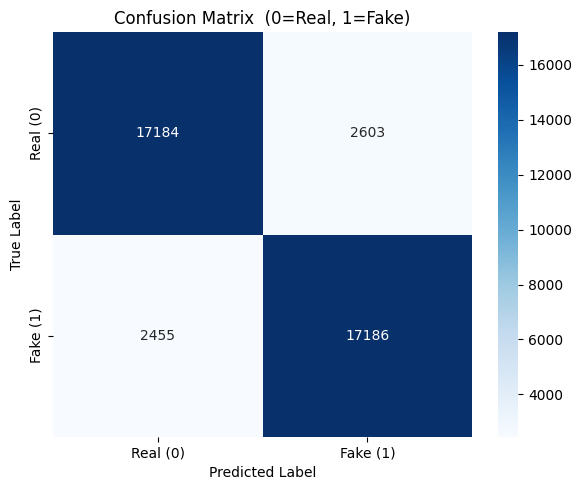


Classification Report:
              precision    recall  f1-score   support

        Real       0.87      0.87      0.87     19787
        Fake       0.87      0.88      0.87     19641

    accuracy                           0.87     39428
   macro avg       0.87      0.87      0.87     39428
weighted avg       0.87      0.87      0.87     39428


=== VERIFY MODEL DIRECTION ===
  [✅] True=Real  sigmoid=0.0500  predicted=Real
  [✅] True=Real  sigmoid=0.3096  predicted=Real
  [❌] True=Real  sigmoid=0.9727  predicted=Fake
  [✅] True=Real  sigmoid=0.0002  predicted=Real
  [✅] True=Real  sigmoid=0.0294  predicted=Real


In [ ]:
# ── CONFUSION MATRIX ──────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true, y_pred_prob = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_pred = [1 if p >= 0.5 else 0 for p in y_pred_prob]

# ✅ Labels: 0=Real, 1=Fake
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.title('Confusion Matrix  (0=Real, 1=Fake)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/Dataset/Dataset/confusion_matrix.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# ✅ Verify model direction: a real image should score LOW sigmoid
print('\n=== VERIFY MODEL DIRECTION ===')
sample_images, sample_labels = next(iter(val_ds))
sample_preds = model.predict(sample_images[:5], verbose=0).flatten()
for i, (pred, true) in enumerate(zip(sample_preds, sample_labels[:5].numpy())):
    true_str = 'Real' if true == 0 else 'Fake'
    pred_str = 'Fake' if pred >= 0.5 else 'Real'
    ok       = '✅' if true_str == pred_str else '❌'
    print(f'  [{ok}] True={true_str}  sigmoid={pred:.4f}  predicted={pred_str}')

In [ ]:
# ── SAVE & DOWNLOAD ───────────────────────────────────────────────────────
model.save(MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')
print('Label convention: 0=Real  1=Fake')
print('Preprocessing  : x/255.0  [0,1]')
print('INVERT_SIGMOID : False  (HIGH sigmoid = FAKE)')

from google.colab import files
files.download(MODEL_PATH)

Model saved to: /content/Dataset/Dataset/deepfake_model.h5
Label convention: 0=Real  1=Fake
Preprocessing  : x/255.0  [0,1]
INVERT_SIGMOID : False  (HIGH sigmoid = FAKE)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>